In [1]:
import jax.numpy as jnp

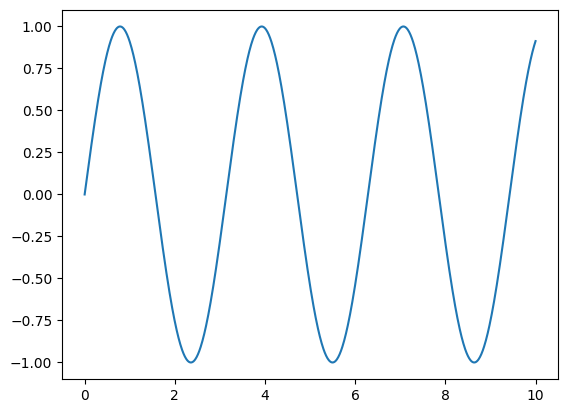

In [2]:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp, y_jnp)

In [3]:
import numpy as np
import jax.numpy as jnp

x_np = np.linspace(0, 10, 1000)
x_jnp = jnp.linspace(0, 10, 1000)

In [4]:
type(x_np)

numpy.ndarray

In [5]:
type(x_jnp)

jaxlib._jax.ArrayImpl

In [6]:
x = np.arange(10)
x[0] = 10
print(x)

[10  1  2  3  4  5  6  7  8  9]


In [7]:
try:
    x = jnp.arange(10)
    x[0] = 10
except Exception as ex:
    print("Exception: ", ex)

Exception:  JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html


In [8]:
y = x.at[0].set(10)

In [9]:
y

Array([10,  1,  2,  3,  4,  5,  6,  7,  8,  9], dtype=int32)

In [10]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
isinstance(x, jax.Array)

True

In [11]:
type(x)

jaxlib._jax.ArrayImpl

In [12]:
x.devices()

{CpuDevice(id=0)}

In [13]:
x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

In [14]:
import jax.numpy as jnp

def norm(X):
    X = X - X.mean(0)
    return X / X.std(0)
    

In [15]:
from jax import jit
norm_compiled = jit(norm)

In [16]:
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))

In [17]:
np.allclose(norm(X), norm_compiled(X), atol=1E-6)

True

In [18]:
%timeit norm(X).block_until_ready()

251 μs ± 9.53 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [19]:
%timeit norm_compiled(X).block_until_ready()

222 μs ± 14.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [20]:
X = jnp.array(np.random.rand(100, 10))

In [21]:
norm_compiled(X)

Array([[-3.68465722e-01,  1.47781515e+00, -6.61420703e-01,
         1.07964838e+00,  7.29025304e-01, -1.08423531e+00,
        -1.41155136e+00, -1.10221028e+00,  1.00606334e+00,
         4.92336750e-01],
       [-3.06827426e-01,  1.31811118e+00, -1.11548924e+00,
         2.26427063e-01,  6.11848772e-01,  1.65540707e+00,
        -1.11477005e+00, -6.18750989e-01,  1.97207704e-01,
         9.10605431e-01],
       [ 9.43820402e-02,  6.25111222e-01,  9.31411326e-01,
        -3.47752869e-01,  1.08371091e+00,  1.03415823e+00,
         1.14014661e+00, -6.35760665e-01, -1.19529009e+00,
        -5.02477884e-01],
       [-7.48544335e-01, -6.95980072e-01,  1.22151721e+00,
        -1.36193049e+00, -9.77216065e-01,  3.07372749e-01,
         4.41571847e-02,  9.53780890e-01, -5.97113073e-01,
        -3.36492002e-01],
       [-6.58427954e-01,  1.37417865e+00, -2.42826238e-01,
         1.40861392e+00,  1.43087971e+00,  1.58283460e+00,
         8.84215474e-01,  8.40774298e-01,  1.19063330e+00,
         2.

In [22]:
norm_compiled(X).shape

(100, 10)

In [23]:
X = jnp.array(np.random.rand(100, 10, 3))

In [24]:
norm_compiled(X)

Array([[[-1.3232098 ,  1.1988403 , -1.363619  ],
        [-0.8210793 , -1.1904706 , -1.117794  ],
        [-1.414214  , -0.60765046,  1.3427817 ],
        ...,
        [ 0.86456335,  0.00797037, -0.83062494],
        [ 0.8027197 ,  0.9362001 , -1.0088943 ],
        [ 0.9444467 ,  1.7166921 ,  0.73036826]],

       [[ 0.6207602 ,  1.5712445 , -0.16780268],
        [ 1.3467267 ,  0.526349  , -0.3237488 ],
        [-1.1640433 ,  0.2936631 , -1.7366958 ],
        ...,
        [-0.30176353, -1.3715981 , -0.52440023],
        [ 1.1865743 , -1.371436  ,  0.19721666],
        [ 0.8698892 , -1.2333846 , -1.6263146 ]],

       [[ 1.0459933 ,  0.13808976, -0.6232782 ],
        [-1.112023  ,  0.7224412 , -0.5230777 ],
        [-1.4186796 ,  1.1775541 ,  1.4053886 ],
        ...,
        [ 0.24727128, -1.4239022 ,  0.37935928],
        [-0.82278174, -0.371612  , -1.6937311 ],
        [-1.5247166 ,  0.64680344, -1.4330249 ]],

       ...,

       [[-0.35380346, -1.2894744 , -0.19581503],
        [ 0

In [25]:
def get_negatives(x):
    return x[x < 0]

x = jnp.array(np.random.randn(10))
get_negatives(x)

Array([-0.5221176 , -1.0559425 , -0.59259987, -0.8337307 , -1.1739215 ,
       -1.2179174 , -0.10215987], dtype=float32)

In [26]:
try:
    jit(get_negatives)(x)
except Exception as ex:
    print("Exception:", ex)

Exception: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError


In [27]:
from jax import grad

def sum_logistic(x):
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)


In [28]:
x_small

Array([0., 1., 2.], dtype=float32)

In [29]:
derivative_fn = grad(sum_logistic)

In [30]:
derivative_fn

<function __main__.sum_logistic(x)>

In [31]:
derivative_fn(x_small)

Array([0.25      , 0.19661197, 0.10499357], dtype=float32)

In [32]:
sum_logistic(x_small)

Array(2.1118555, dtype=float32)

In [33]:
jnp.eye(len(x_small))

Array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [34]:
for v in jnp.eye(len(x_small)):
    print(v)

[1. 0. 0.]
[0. 1. 0.]
[0. 0. 1.]


In [35]:
def first_finite_differences(f, x, eps=1E-3):
    return jnp.array([(f(x + eps * v) - f(x - eps * v)) / (2 * eps)
                      for v in jnp.eye(len(x))])

print(first_finite_differences(sum_logistic, x_small))

[0.24998187 0.1964569  0.10502338]


In [36]:
from jax import jacobian
print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [37]:
try:
    print(grad(jnp.exp)(x_small))
except Exception as ex:
    print("Exception", ex)

Exception Gradient only defined for scalar-output functions. Output had shape: (3,).


In [38]:
jnp.exp(x_small)

Array([1.       , 2.7182817, 7.389056 ], dtype=float32)

In [39]:
def foo(X):
    return jnp.sum(jnp.exp(X))

In [40]:
grad(foo)

<function __main__.foo(X)>

In [41]:
grad(foo)(x_small)

Array([1.       , 2.7182817, 7.389056 ], dtype=float32)

In [42]:
X

Array([[[1.9447577e-01, 8.6155289e-01, 8.1864923e-02],
        [2.3749557e-01, 2.3620483e-01, 2.3266567e-01],
        [6.9267452e-02, 3.4158897e-01, 8.3953923e-01],
        ...,
        [7.6402074e-01, 4.4054982e-01, 2.2577950e-01],
        [7.9155135e-01, 7.9953396e-01, 2.0143272e-01],
        [7.8477466e-01, 9.5585001e-01, 6.9828123e-01]],

       [[7.2329772e-01, 9.7369045e-01, 4.0375638e-01],
        [8.6978668e-01, 6.8574244e-01, 4.5183000e-01],
        [1.3993901e-01, 5.9232974e-01, 3.0607278e-03],
        ...,
        [4.3527305e-01, 1.6617168e-02, 3.1510428e-01],
        [8.9452040e-01, 1.9627826e-01, 5.4455876e-01],
        [7.6388007e-01, 1.3599204e-01, 4.5157862e-03]],

       [[8.3897471e-01, 5.4214203e-01, 2.8115085e-01],
        [1.5263505e-01, 7.3708785e-01, 3.9681324e-01],
        [6.8005979e-02, 8.3822364e-01, 8.5654515e-01],
        ...,
        [5.9002721e-01, 5.4447778e-04, 5.7872802e-01],
        [3.5551035e-01, 4.5764941e-01, 6.6037923e-03],
        [9.2796460e-02

In [43]:
from jax import random

In [44]:
key = random.key(1701)

In [45]:
key


Array((), dtype=key<fry>) overlaying:
[   0 1701]

In [46]:
key1, key2 = random.split(key)

In [47]:
key1, key2

(Array((), dtype=key<fry>) overlaying:
 [ 741045208 1847055613],
 Array((), dtype=key<fry>) overlaying:
 [  85238482 2594297577])

In [48]:
key = random.key(1701)

In [49]:
key1, key2 = random.split(key)

In [50]:
key1, key2

(Array((), dtype=key<fry>) overlaying:
 [ 741045208 1847055613],
 Array((), dtype=key<fry>) overlaying:
 [  85238482 2594297577])

In [51]:
mat = random.normal(key1, (150, 100))

In [52]:
mat

Array([[-1.304116  , -0.62097436,  0.15579857, ...,  0.56307614,
        -0.02334534, -0.696136  ],
       [-0.36737335,  1.1275479 , -0.8342158 , ...,  0.12688479,
         0.09017282, -1.5691686 ],
       [ 0.1537866 ,  0.8126355 ,  0.76753694, ...,  0.10912927,
         0.03468043,  3.9337554 ],
       ...,
       [-1.7988143 , -1.5725353 ,  0.0990397 , ..., -1.374228  ,
         0.7167976 ,  1.0613726 ],
       [ 0.37561414, -0.7576286 , -1.134148  , ...,  0.82601506,
         0.44193715, -0.3719684 ],
       [ 0.320369  ,  0.22578898,  0.36521432, ..., -0.54081446,
        -0.1091117 ,  0.40976334]], dtype=float32)

In [53]:
batched_x = random.normal(key2, (10, 100))

In [54]:
batched_x.shape

(10, 100)

In [55]:
def apply_matrix(x):
    return jnp.dot(mat, x)

In [56]:
@jit
def naively_batched_apply_matrix(v_batched):
    return jnp.stack([apply_matrix(v) for v in v_batched])

In [57]:
print("Naively batched")
%timeit naively_batched_apply_matrix(batched_x).block_until_ready()

Naively batched
21.9 μs ± 728 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [58]:
import numpy as np

@jit
def batched_apply_matrix(batched_x):
    return jnp.dot(batched_x, mat.T)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           batched_apply_matrix(batched_x),
                           atol=1E-4, rtol=1E-4)
print("Manually batched")
%timeit batched_apply_matrix(batched_x).block_until_ready()

Manually batched
12.9 μs ± 248 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [59]:
from jax import vmap

@jit
def vmap_batched_apply_matrix(batched_x):
    return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           vmap_batched_apply_matrix(batched_x), 
                           atol=1E-4, rtol=1E-4)
print("Auto-vectorised with vmap")
%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

Auto-vectorised with vmap
15.1 μs ± 499 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [60]:
from jax import random

key = random.key(43)
print(key)

Array((), dtype=key<fry>) overlaying:
[ 0 43]


In [62]:
print(random.normal(key))
print(random.normal(key))

0.07520543
0.07520543


In [65]:
import jax
import jax.numpy as jnp

@jit
def f(x):
    print(x)
    y = jnp.sin(x)
    print(y)
    return y

result = f(2.)

JitTracer(~float32[])
JitTracer(~float32[])


In [69]:
import jax
import jax.numpy as jnp

@jit
def f(x):
    jax.debug.print("{x}", x=x)
    y = jnp.sin(x)
    jax.debug.print("{y}", y=y)
    return y

result = f(2.)


2.0
0.9092974066734314
